In [1]:
import numpy as np

from borf import BORF
from downtime import load_dataset
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from borf.xai.borf_shap_explainer import BorfShapExplainer
import matplotlib.pyplot as plt

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
d = load_dataset("CBF")
X_train, y_train, X_test, y_test = d()
labels = ["cylinder", "bell", "funnel"]
print(d)

X_train: (30, 1, 128)
X_test: (900, 1, 128)
y_train: (30,)
y_test: (900,)
Metadata:
{'labels': {'0': '1', '1': '2', '2': '3'},
 'name': 'CBF',
 'task': 'classification'}


In [15]:
pipe = make_pipeline(BORF(n_jobs=-1), LinearSVC())
pipe.fit(X_train, y_train)

The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.


1.0

In [16]:
exp = BorfShapExplainer(
    transformer=pipe[0],
    pipeline=pipe,
    labels=labels,
    X_shapes_ratio=0.2
)

In [30]:
i = 1
x = X_test[i:i+1]
print("y = ", labels[y_test[i]], ";", "y_pred = ", labels[pipe.predict(x)[0]])

y =  bell ; y_pred =  bell


In [31]:
%%time
exp.fit(X_train)

CPU times: user 68.9 ms, sys: 10 ms, total: 78.9 ms
Wall time: 390 ms


# Explanations
For now there are 3 types of explanations, from fast to slow:
- features: compute the importance of each word
- features_saliency: compute the importance of each word and the saliency map
- features_shapes_saliency: compute the importance of each word, the saliency map and the shape of the receptive fields

## Features

In [32]:
%%time
e = exp.explain(x, explanation_type="features")[0]

CPU times: user 199 ms, sys: 97.3 ms, total: 296 ms
Wall time: 484 ms


In [33]:
# feature importance towards the predicted label for i
word_importance = (
    e.word_importance[:, :, y_test[i]]
    .to_pandas()
    .T.sort_values(by="abs_shap_values", ascending=False)
)
word_importance

rows,feature_idxs,signal_idxs,shap_values,abs_shap_values,shap_values_length_ratio,abs_shap_values_length_ratio,counts
words,,,,,,,
"2_3_1_1_64_2;0;2.0,2.1",18168.0,0.0,0.119083,0.119083,0.001861,0.001861,41.0
"2_3_1_1_32_2;0;2.0,2.1",12108.0,0.0,0.116899,0.116899,0.003653,0.003653,35.0
2_3_1_1_32_1;0;2.0,12098.0,0.0,0.081050,0.081050,0.002533,0.002533,44.0
2_3_1_1_64_1;0;0.1,18164.0,0.0,-0.057970,0.057970,-0.000906,0.000906,1.0
"2_3_2_1_32_2;0;2.0,2.1",15609.0,0.0,0.041951,0.041951,0.001311,0.001311,36.0
...,...,...,...,...,...,...,...
"2_3_4_1_16_8;0;0.0,2.0,2.0,0.0,1.1,0.1,0.1,0.1",11330.0,0.0,-0.000000,0.000000,-0.000000,0.000000,0.0
"2_3_4_1_16_8;0;0.0,0.0,2.0,0.0,0.0,2.1,0.1,0.1",11331.0,0.0,-0.000000,0.000000,-0.000000,0.000000,0.0
"2_3_4_1_16_8;0;2.0,2.0,2.0,2.0,0.0,0.1,2.1,0.1",11332.0,0.0,-0.000000,0.000000,-0.000000,0.000000,0.0


## Features Saliency

In [34]:
%%time
e = exp.explain(x, explanation_type="features_saliency")[0]

CPU times: user 48.1 s, sys: 554 ms, total: 48.7 s
Wall time: 49.4 s


[array([[<Axes: >]], dtype=object),
 array([[<Axes: >]], dtype=object),
 array([[<Axes: >]], dtype=object)]

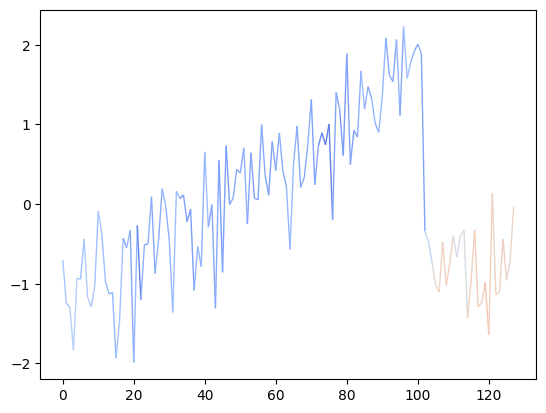

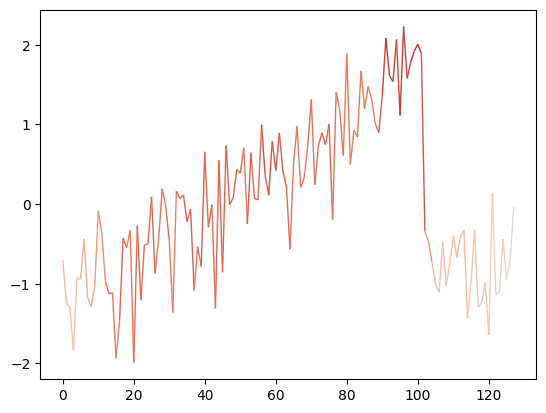

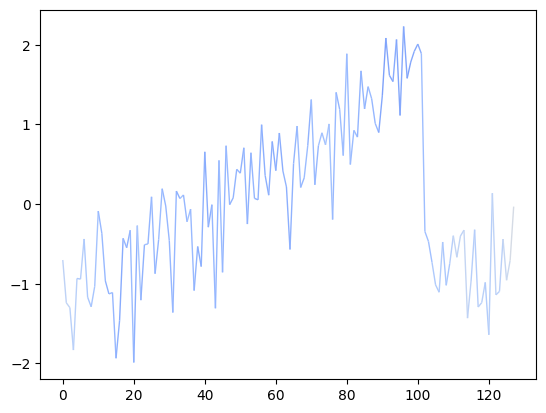

In [35]:
# plots the saliency map for each possible label
e.plot_saliency()

## Features Shapes Saliency

In [37]:
%%time
e = exp.explain(x, explanation_type="features_shapes_saliency")[0]

Mean of empty slice.
invalid value encountered in scalar divide


CPU times: user 2min 36s, sys: 1.96 s, total: 2min 38s
Wall time: 2min 39s


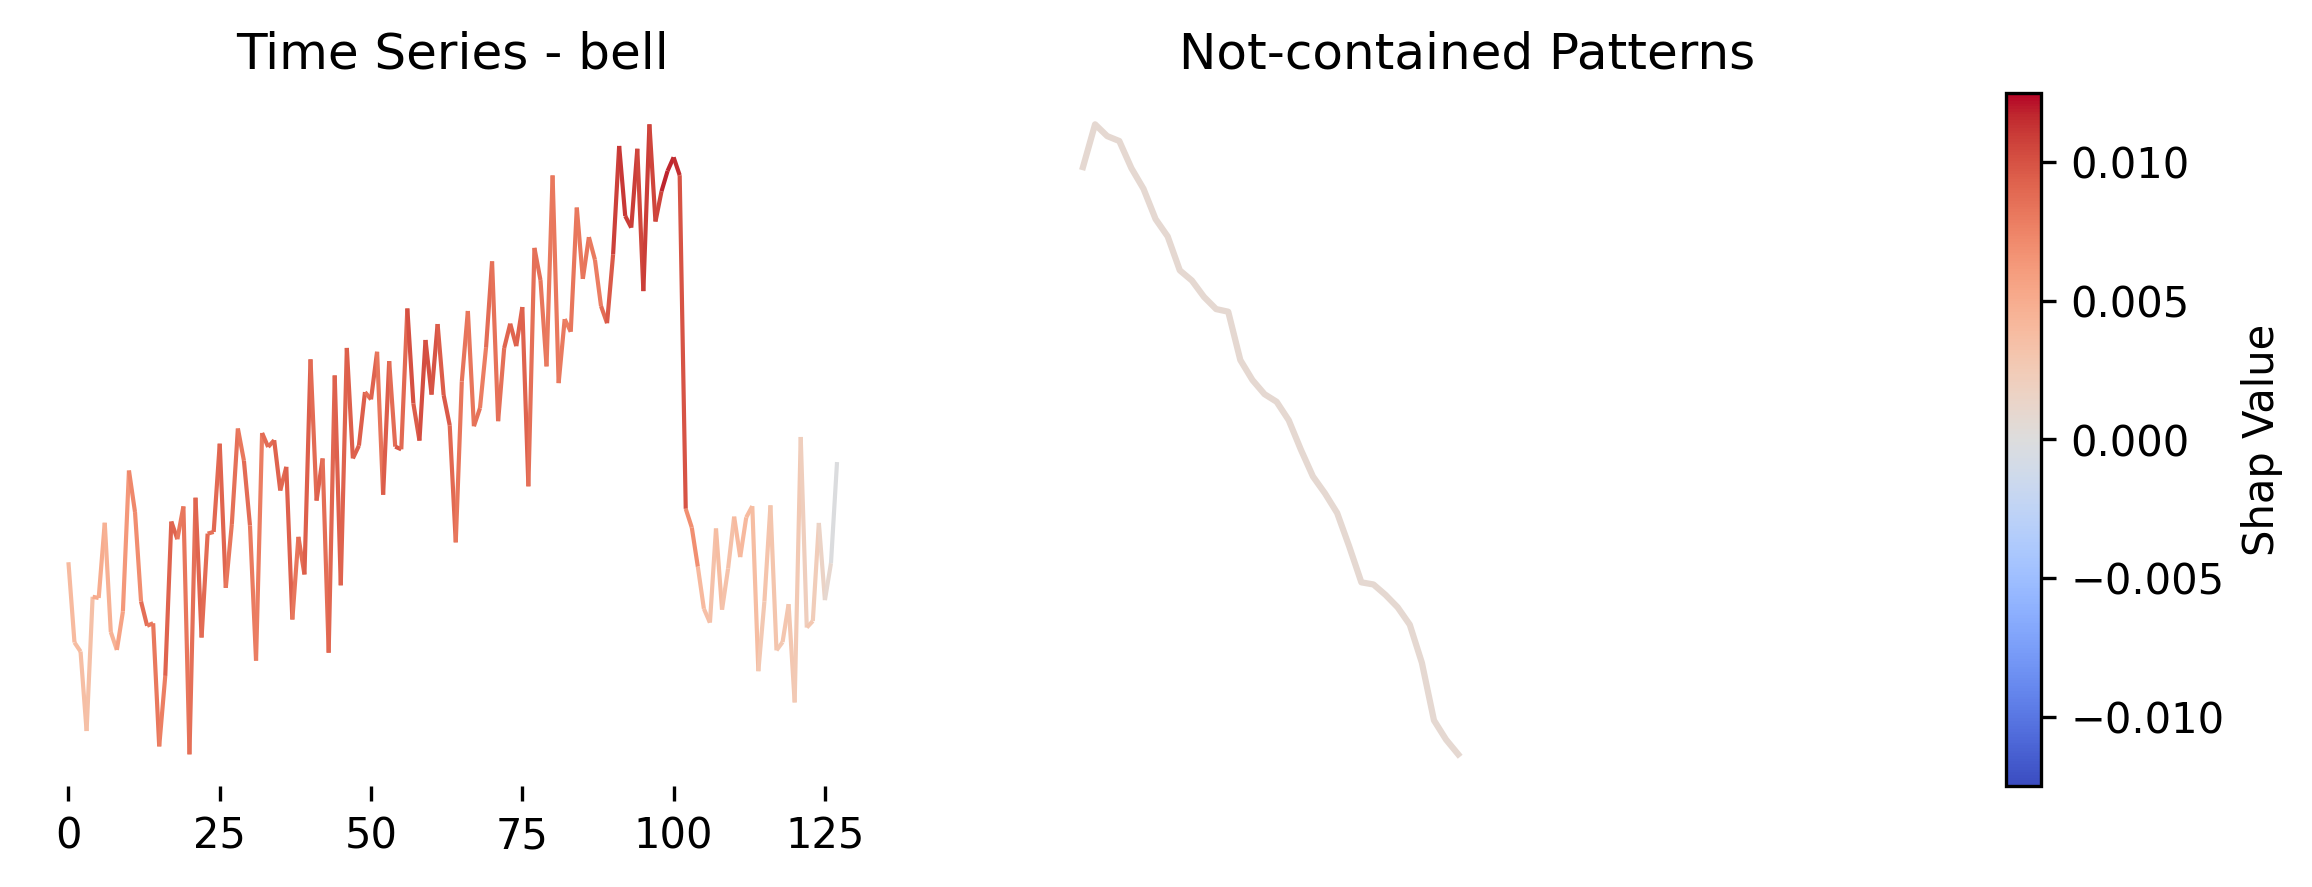

In [38]:
e.plot(figsize=(10, 3))
plt.show()